In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})

import seaborn as sns

import matplotlib
%matplotlib inline


### Example code for 2D KDE

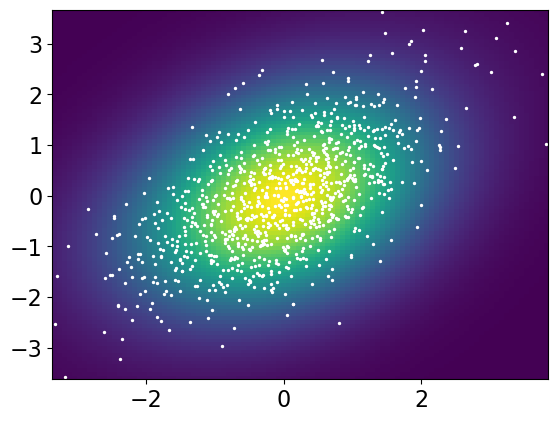

In [98]:
# Source - https://stackoverflow.com/a/41639690
# Posted by Geoffrey, modified by community. See post 'Timeline' for change history
# Retrieved 2026-06-22, License - CC BY-SA 4.0

from sklearn.neighbors import KernelDensity

def kde2D(x, y, bandwidth, xbins=100j, ybins=100j, **kwargs): 
    """Build 2D kernel density estimate (KDE)."""

    # create grid of sample locations (default: 100x100)
    xx, yy = np.mgrid[x.min():x.max():xbins, 
                      y.min():y.max():ybins]

    xy_sample = np.vstack([yy.ravel(), xx.ravel()]).T
    xy_train  = np.vstack([y, x]).T

    kde_skl = KernelDensity(bandwidth=bandwidth, **kwargs)
    
    kde_skl.fit(xy_train)
    
    # score_samples() returns the log-likelihood of the samples
    z = np.exp(kde_skl.score_samples(xy_sample))
    return xx, yy, np.reshape(z, xx.shape)


def kde2D_weights(x, y, bandwidth, sample_weight, xbins=100j, ybins=100j, **kwargs): 
    """Build 2D kernel density estimate (KDE)."""

    # create grid of sample locations (default: 100x100)
    xx, yy = np.mgrid[x.min():x.max():xbins, 
                      y.min():y.max():ybins]

    xy_sample = np.vstack([yy.ravel(), xx.ravel()]).T
    xy_train  = np.vstack([y, x]).T

    kde_skl = KernelDensity(bandwidth=bandwidth, **kwargs)
    
    kde_skl.fit(xy_train, sample_weight) # sample weight will be used for our various "risk outcomes"

    # score_samples() returns the log-likelihood of the samples
    z = np.exp(kde_skl.score_samples(xy_sample))
    return xx, yy, np.reshape(z, xx.shape)

# Source - https://stackoverflow.com/a/41639690
# Posted by Geoffrey, modified by community. See post 'Timeline' for change history
# Retrieved 2026-06-22, License - CC BY-SA 4.0

import numpy as np
import matplotlib.pyplot as plt

m1 = np.random.normal(size=1000)
m2 = np.random.normal(scale=0.5, size=1000)

x, y = m1 + m2, m1 - m2

xx, yy, zz = kde2D(x, y, 1.0)

plt.pcolormesh(xx, yy, zz)
plt.scatter(x, y, s=2, facecolor='white')


In [33]:
data = pd.read_csv('tidy_tornado_data.csv')
data.keys()

/tmp/ipykernel_180826/4010725377.py:1: DtypeWarning: Columns (0: TOR_OTHER_WFO, 1: TOR_OTHER_CZ_STATE, 2: TOR_OTHER_CZ_NAME) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('tidy_tornado_data.csv')


Index(['EPISODE_ID', 'EVENT_ID', 'STATE_FIPS', 'YEAR', 'MONTH_NAME',
       'EVENT_TYPE', 'INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DEATHS_DIRECT',
       'DEATHS_INDIRECT', 'DAMAGE_PROPERTY', 'DAMAGE_CROPS', 'SOURCE',
       'CATEGORY', 'TOR_F_SCALE', 'TOR_LENGTH', 'TOR_WIDTH', 'TOR_OTHER_WFO',
       'TOR_OTHER_CZ_STATE', 'TOR_OTHER_CZ_FIPS', 'TOR_OTHER_CZ_NAME',
       'BEGIN_RANGE', 'BEGIN_AZIMUTH', 'BEGIN_LOCATION', 'END_RANGE',
       'END_AZIMUTH', 'BEGIN_LAT', 'BEGIN_LON', 'END_LAT', 'END_LON',
       'DATA_SOURCE', 'YEARMONTH'],
      dtype='str')

In [34]:
keys = ['END_LAT', 'END_LON', 'YEARMONTH', 'INJURIES_DIRECT', 'INJURIES_DIRECT'] 

filter_arr = np.array(data[keys[0]].isna() == False)

for n in range(1,len(keys)):
    filter_arr *= np.array(data[keys[n]].isna() == False) 

data_f = data[filter_arr]
print(len(data), len(data_f))


# year = []
# month = []
# for n in range(0,len(data_f)):
#     year_in, month_in, date_in = np.array(data_f['YEARMONTH'])[n].split('-')
#     year.append(year_in)
#     month.append(month_in)

# data_f['year'] = np.array([int(m) for m in year])
# data_f['month'] = np.array([int(m) for m in month])

49437 44052


In [35]:
data_f

,EPISODE_ID,EVENT_ID,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,INJURIES_DIRECT,INJURIES_INDIRECT,DEATHS_DIRECT,DEATHS_INDIRECT,...,BEGIN_AZIMUTH,BEGIN_LOCATION,END_RANGE,END_AZIMUTH,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,DATA_SOURCE,YEARMONTH
1,1182775.0,5430397,6.0,2004,December,Tornado,0,0,0,0,...,NaN,SANTA ROSA,NaN,NaN,38.45000,-122.70000,38.45000,-122.70000,PDS,2004-12-01
2,1182727.0,5430610,28.0,2004,December,Tornado,0,0,0,0,...,SW,DE KALB,2.0,SW,32.23333,-89.43333,32.28333,-89.38333,PDS,2004-12-01
3,1182686.0,5430497,18.0,2004,December,Tornado,0,0,0,0,...,SW,SANDUSKY,2.0,SW,39.40000,-85.50000,39.41667,-85.48333,PDS,2004-12-01
4,1183227.0,5431177,15.0,2004,February,Tornado,0,0,0,0,...,SE,PAHALA,2.0,SE,19.18333,-155.46667,19.41667,-155.23333,PDS,2004-02-01
5,1190714.0,5431956,51.0,2004,September,Tornado,0,0,0,0,...,SE,MANASSAS,2.0,SE,38.73333,-77.46667,38.76667,-77.45000,PDS,2004-09-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49432,2408261.0,5700830,40.0,1999,May,Tornado,0,0,0,0,...,S,BRAGGS,1.0,S,35.67000,-95.20000,35.67000,-95.20000,PDC,1999-05-01
49433,2409105.0,5704593,20.0,1999,June,Tornado,0,0,0,0,...,NW,LAKIN,22.0,NW,38.18000,-101.53000,38.17000,-101.53000,PDC,1999-06-01
49434,2409105.0,5704595,20.0,1999,June,Tornado,0,0,0,0,...,NW,LAKIN,22.0,NW,38.18000,-101.53000,38.17000,-101.53000,PDC,1999-06-01
49435,2409105.0,5704598,20.0,1999,June,Tornado,0,0,0,0,...,NW,LAKIN,19.0,NW,38.15000,-101.50000,38.15000,-101.50000,PDC,1999-06-01


<>:30: SyntaxWarning: invalid escape sequence '\c'
<>:31: SyntaxWarning: invalid escape sequence '\c'
<>:65: SyntaxWarning: invalid escape sequence '\c'
<>:66: SyntaxWarning: invalid escape sequence '\c'
<>:30: SyntaxWarning: invalid escape sequence '\c'
<>:31: SyntaxWarning: invalid escape sequence '\c'
<>:65: SyntaxWarning: invalid escape sequence '\c'
<>:66: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_180826/2109217758.py:30: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('LON [$^\circ$]')
/tmp/ipykernel_180826/2109217758.py:31: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('LAT [$^\circ$]')
/tmp/ipykernel_180826/2109217758.py:65: SyntaxWarning: invalid escape sequence '\c'
  ax[n].set_xlabel('LON [$^\circ$]')
/tmp/ipykernel_180826/2109217758.py:66: SyntaxWarning: invalid escape sequence '\c'
  ax[n].set_ylabel('LAT [$^\circ$]')


./data/1990_tornados.csv
./data/1991_tornados.csv
./data/1992_tornados.csv
./data/1993_tornados.csv
./data/1994_tornados.csv
./data/1995_tornados.csv
./data/1996_tornados.csv
./data/1997_tornados.csv
./data/1998_tornados.csv
./data/1999_tornados.csv
./data/2000_tornados.csv
./data/2001_tornados.csv
./data/2002_tornados.csv
./data/2003_tornados.csv
./data/2004_tornados.csv
./data/2005_tornados.csv
./data/2006_tornados.csv
./data/2007_tornados.csv
./data/2008_tornados.csv
./data/2009_tornados.csv
./data/2010_tornados.csv
./data/2011_tornados.csv
./data/2012_tornados.csv
./data/2013_tornados.csv
./data/2014_tornados.csv
./data/2015_tornados.csv
./data/2016_tornados.csv
./data/2017_tornados.csv
./data/2018_tornados.csv
./data/2019_tornados.csv
./data/2020_tornados.csv
./data/2021_tornados.csv
./data/2022_tornados.csv
./data/2023_tornados.csv
./data/2024_tornados.csv
./data/2025_tornados.csv


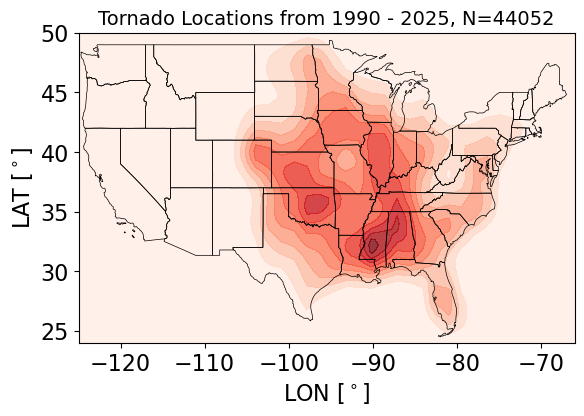



In [90]:
import geopandas as gpd
states = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_state_20m.zip"
)

states = states[
    ~states["STUSPS"].isin(["PR", "GU", "VI", "AS", "MP"])
]


xx, yy, zz = kde2D(data_f['BEGIN_LON'],data_f['BEGIN_LAT'], 1.0)
plt.contourf(
    xx,
    yy,
    zz,
    levels=10,
    cmap="Reds",
    alpha=0.8
)

states.boundary.plot(
    ax=plt.gca(),
    color="black",
    linewidth=0.5
)

plt.xlim(-125, -66)
plt.ylim(24, 50)

plt.xlabel('LON [$^\circ$]')
plt.ylabel('LAT [$^\circ$]')

plt.title('Tornado Locations from 1990 - 2025, N='+str(len(data_f)), fontsize=14)

import glob
df_all = glob.glob('./data/*_tornados.csv')

df_all = np.sort(df_all)

fig, ax = plt.subplots(len(df_all),1, figsize=(7,5*len(df_all)))
fig.subplots_adjust(hspace=0.45)

for n in range(0,len(df_all)):
    print(df_all[n])
    df = pd.read_csv(df_all[n])
    xx, yy, zz = kde2D(df['BEGIN_LON'],df['BEGIN_LAT'], 1.0)
    ax[n].contourf(
        xx,
        yy,
        zz,
        levels=10,
        cmap="Reds",
        alpha=0.8
    )
    
    states.boundary.plot(
        ax=ax[n],#plt.gca(),
        color="black",
        linewidth=0.5
    )
    
    ax[n].set_xlim(-125, -66)
    ax[n].set_ylim(24, 50)
    
    ax[n].set_xlabel('LON [$^\circ$]')
    ax[n].set_ylabel('LAT [$^\circ$]')
    
    ax[n].set_title('Tornado Locations in '+str(df['YEAR'][0])+', N='+str(len(df['BEGIN_LON'])))
    

### USE SAMPLE_WEIGHT AS NUMBER OF INJURIES 

<>:34: SyntaxWarning: invalid escape sequence '\c'
<>:35: SyntaxWarning: invalid escape sequence '\c'
<>:34: SyntaxWarning: invalid escape sequence '\c'
<>:35: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_180826/3873652046.py:34: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('LON [$^\circ$]')
/tmp/ipykernel_180826/3873652046.py:35: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('LAT [$^\circ$]')


Text(0.5, 1.0, 'Tornado Locations & Total Injuries (1990 - 2025), N=3288')

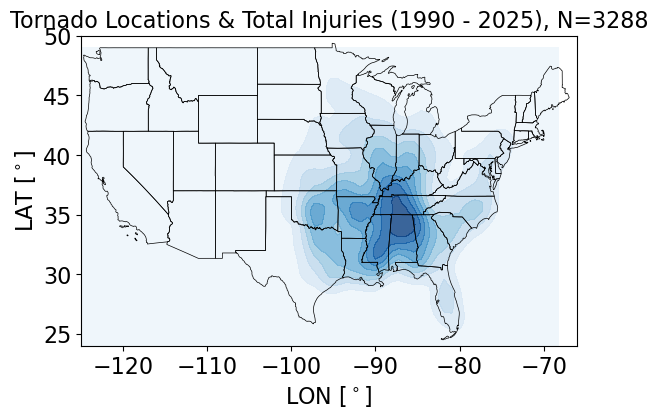

In [106]:
import geopandas as gpd
states = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_state_20m.zip"
)

states = states[
    ~states["STUSPS"].isin(["PR", "GU", "VI", "AS", "MP"])
]

tot_injuries = np.array(data_f['INJURIES_DIRECT'] + data_f['INJURIES_INDIRECT']) 

filter_arr = np.array(tot_injuries > 0)

xx, yy, zz = kde2D_weights(np.array(data_f['BEGIN_LON'])[filter_arr],
                           np.array(data_f['BEGIN_LAT'])[filter_arr], 1.0, sample_weight=tot_injuries[filter_arr])
plt.contourf(
    xx,
    yy,
    zz,
    levels=10,
    cmap="Blues",
    alpha=0.8
)

states.boundary.plot(
    ax=plt.gca(),
    color="black",
    linewidth=0.5
)

plt.xlim(-125, -66)
plt.ylim(24, 50)

plt.xlabel('LON [$^\circ$]')
plt.ylabel('LAT [$^\circ$]')

plt.title('Tornado Locations & Total Injuries (1990 - 2025), N='+str(np.sum(filter_arr)), fontsize=16)

<>:37: SyntaxWarning: invalid escape sequence '\c'
<>:38: SyntaxWarning: invalid escape sequence '\c'
<>:37: SyntaxWarning: invalid escape sequence '\c'
<>:38: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_180826/387563319.py:37: SyntaxWarning: invalid escape sequence '\c'
  ax[n].set_xlabel('LON [$^\circ$]')
/tmp/ipykernel_180826/387563319.py:38: SyntaxWarning: invalid escape sequence '\c'
  ax[n].set_ylabel('LAT [$^\circ$]')


./data/1990_tornados.csv
./data/1991_tornados.csv
./data/1992_tornados.csv
./data/1993_tornados.csv
./data/1994_tornados.csv
./data/1995_tornados.csv
./data/1996_tornados.csv
./data/1997_tornados.csv
./data/1998_tornados.csv
./data/1999_tornados.csv
./data/2000_tornados.csv
./data/2001_tornados.csv
./data/2002_tornados.csv
./data/2003_tornados.csv
./data/2004_tornados.csv
./data/2005_tornados.csv
./data/2006_tornados.csv
./data/2007_tornados.csv
./data/2008_tornados.csv
./data/2009_tornados.csv
./data/2010_tornados.csv
./data/2011_tornados.csv
./data/2012_tornados.csv
./data/2013_tornados.csv
./data/2014_tornados.csv
./data/2015_tornados.csv
./data/2016_tornados.csv
./data/2017_tornados.csv
./data/2018_tornados.csv
./data/2019_tornados.csv
./data/2020_tornados.csv
./data/2021_tornados.csv
./data/2022_tornados.csv
./data/2023_tornados.csv
./data/2024_tornados.csv
./data/2025_tornados.csv




In [119]:
import glob
df_all = glob.glob('./data/*_tornados.csv')

df_all = np.sort(df_all)

fig, ax = plt.subplots(len(df_all),1, figsize=(7,5*len(df_all)))
fig.subplots_adjust(hspace=0.45)

for n in range(0,len(df_all)):
    print(df_all[n])
    df = pd.read_csv(df_all[n])

    tot_injuries = np.array(df['INJURIES_DIRECT']) + np.array(df['INJURIES_INDIRECT']) 

    filter_arr = np.array(tot_injuries > 0)
    
    xx, yy, zz = kde2D_weights(np.array(df['BEGIN_LON'])[filter_arr],
                               np.array(df['BEGIN_LAT'])[filter_arr], 1.0, sample_weight=tot_injuries[filter_arr])
    plt.contourf(
        xx,
        yy,
        zz,
        levels=10,
        cmap="Blues",
        alpha=0.8
    )

    states.boundary.plot(
        ax=ax[n],#plt.gca(),
        color="black",
        linewidth=0.5
    )
    
    ax[n].set_xlim(-125, -66)
    ax[n].set_ylim(24, 50)
    
    ax[n].set_xlabel('LON [$^\circ$]')
    ax[n].set_ylabel('LAT [$^\circ$]')
    
    ax[n].set_title('Tornado Locations & Total Injuries ('+str(df['YEAR'][0])+'), N='+str(np.sum(filter_arr)))
    

### Is KDE the answer? We want to learn a model between location and risk outcome. KDE learns the probability distribution, but it is less obvious to evaluate or test what it has learned.

## RandomForest might be a better way to go

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_validate, KFold, cross_val_predict, GridSearchCV
import numpy as np

import matplotlib
plt.rcParams.update({'font.size': 12, 'text.usetex': False})
matplotlib.rc('font', family='serif')

In [3]:
df_all = pd.read_csv('~/summer26-twister/data/tidy_tornado_data.csv')

/tmp/ipykernel_260203/315138064.py:1: DtypeWarning: Columns (0: TOR_OTHER_WFO, 1: TOR_OTHER_CZ_STATE, 2: TOR_OTHER_CZ_NAME) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv('~/summer26-twister/data/tidy_tornado_data.csv')


In [8]:
df_filt = df_all[df_all['BEGIN_LAT'].isna() == False]

In [12]:
import json

# Open the file and load its contents
with open('/home/dilys/summer26-twister/data/raw/nexrad_sites.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

# The data is now a standard Python dictionary or list
#print(data)

radar = pd.DataFrame(data['features'])

radar_names = radar['id']

dict_radar = {}
rad_lon = []
rad_lat = []
rad_name = []

for n in range(0,len(radar_names)):
    id_name = data['features'][n]['properties']['name']
    if data['features'][n]['properties']['rda'] == None:
        print(id_name, ' has no rda info')
    elif str(data['features'][n]['properties']['rda']['properties']['status']) == 'Operate':
        dict_radar[id_name] = {}
        coordinates = data['features'][n]['geometry']['coordinates']
        dict_radar[id_name]['LAT'] = coordinates[1]
        dict_radar[id_name]['LON'] = coordinates[0]
    
        rad_name.append(id_name)
        rad_lon.append(coordinates[0])
        rad_lat.append(coordinates[1])

#print(len(rad_name), ' out of ', len(radar_names), ' have status == Operate')

# df_radars = {
#     'Name': rad_name,
#     'LAT': rad_lat,
#     'LON': rad_lon,
#     'RANGE_km': [430]*len(rad_name)
# }

Kadena AB  has no rda info


In [17]:
data['features']#['geometry']

[{'id': 'https://api.weather.gov/radar/stations/KOKX',
  'type': 'Feature',
  'geometry': {'type': 'Point', 'coordinates': [-72.86392, 40.86552]},
  'properties': {'@id': 'https://api.weather.gov/radar/stations/KOKX',
   '@type': 'wx:RadarStation',
   'id': 'KOKX',
   'name': 'Brookhaven',
   'stationType': 'WSR-88D',
   'elevation': {'unitCode': 'wmoUnit:m', 'value': 25.91},
   'timeZone': 'GMT',
   'latency': {'current': {'unitCode': 'nwsUnit:s', 'value': 0.383728},
    'average': {'unitCode': 'nwsUnit:s', 'value': 0.14},
    'max': {'unitCode': 'nwsUnit:s', 'value': 0},
    'levelTwoLastReceivedTime': '2026-05-28T15:09:57+00:00',
    'maxLatencyTime': '2026-05-28T15:08:09+00:00',
    'reportingHost': 'rdss',
    'host': 'ldm4'},
   'rda': {'timestamp': '2026-05-28T15:08:18+00:00',
    'reportingHost': 'rdss',
    'properties': {'resolutionVersion': 6,
     'nl2Path': 'Default',
     'volumeCoveragePattern': 'R35',
     'controlStatus': 'RPG (Remote) Only',
     'buildNumber': 24.1,


In [13]:
radar['geometry'].centroid

AttributeError: 'Series' object has no attribute 'centroid'

In [143]:
features = pd.DataFrame({
    'BEGIN_LAT': df_filt['BEGIN_LAT'],
    'BEGIN_LON': df_filt['BEGIN_LON'],
    #'MONTH' : df_filt['MONTH'],
    'RADAR_2026': df['RADAR_2026']
})

targets = pd.DataFrame({
    'DEATHS_TOTAL': np.array(df['DEATHS_DIRECT']),
    'DEATHS_INDIRECT': np.array(df['DEATHS_INDIRECT']),
    'INJURIES_DIRECT': np.array(df['INJURIES_DIRECT']),
    'INJURIES_INDIRECT': np.array(df['INJURIES_INDIRECT']),
    'DAMAGE_CROPS': np.array(df['DAMAGE_CROPS']),
    'DAMAGE_PROPERTY': np.array(df['DAMAGE_PROPERTY']),
})

<Axes: >

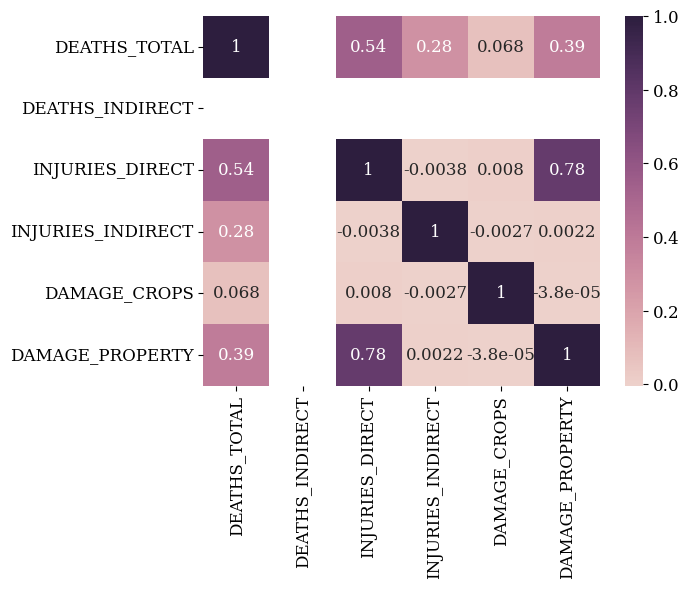

In [144]:
correlation = targets.corr()

plt.figure(facecolor='w')
sns.heatmap(correlation,cmap=sns.cubehelix_palette(as_cmap=True),annot=True)

In [145]:
#As a sanity check let's ensure all of these are the same size
print(len(features), len(targets))

# Scaling  -- do we need this?
# from sklearn import preprocessing
# scaler = preprocessing.StandardScaler().fit(features)
# scaled_spectra = scaler.transform(features)

from sklearn.ensemble import RandomForestRegressor
forest_model = RandomForestRegressor()
CV=KFold(shuffle = True, n_splits = 5, random_state=10) 
scores_models = cross_validate(forest_model, features, targets, cv = CV, return_train_score=True, scoring='r2') #

targets_pred = cross_val_predict(forest_model, features, targets, cv = CV)

scores = []
for i in range(5):
    scores.append(cross_validate(forest_model,features,
                                 targets[targets.columns[i]], 
                                 cv = KFold(n_splits=5, shuffle=True, random_state=10), 
                                 return_train_score=True, scoring = 'r2'))

1244 1244


In [146]:
scores

[{'fit_time': array([0.07208514, 0.07375932, 0.0734303 , 0.0691123 , 0.07240391]),
  'score_time': array([0.00474501, 0.00502586, 0.00465655, 0.00470376, 0.00457644]),
  'test_score': array([-0.06490916, -0.01448755, -0.16172809, -0.61432553, -0.39102992]),
  'train_score': array([0.84669753, 0.82306495, 0.83831442, 0.83719639, 0.81351675])},
 {'fit_time': array([0.04103971, 0.04058886, 0.0404799 , 0.04258919, 0.04119563]),
  'score_time': array([0.00426722, 0.004076  , 0.00409746, 0.0043633 , 0.00402832]),
  'test_score': array([1., 1., 1., 1., 1.]),
  'train_score': array([1., 1., 1., 1., 1.])},
 {'fit_time': array([0.08497667, 0.08921885, 0.08594108, 0.0874064 , 0.08671093]),
  'score_time': array([0.00495887, 0.00502658, 0.00504088, 0.00513482, 0.00517654]),
  'test_score': array([-0.54586112, -1.09600795, -0.05067208, -3.7502663 , -0.17263562]),
  'train_score': array([0.85543949, 0.80601467, 0.83799099, 0.81710262, 0.76572707])},
 {'fit_time': array([0.0492034 , 0.05468988, 0.054

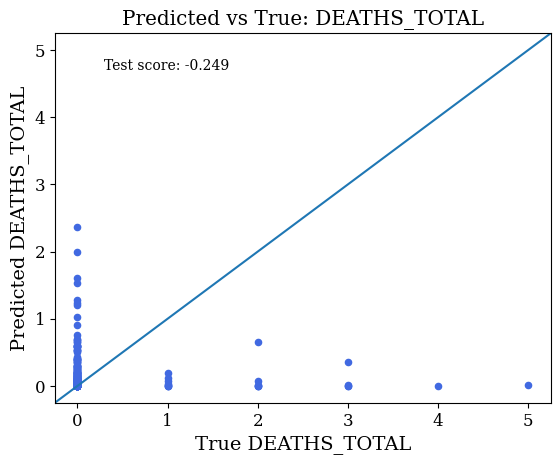

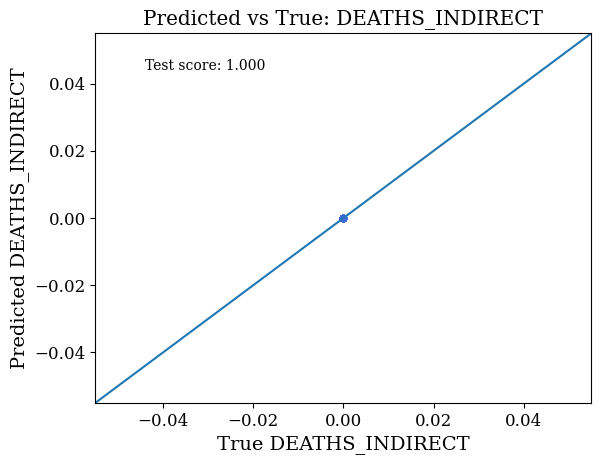

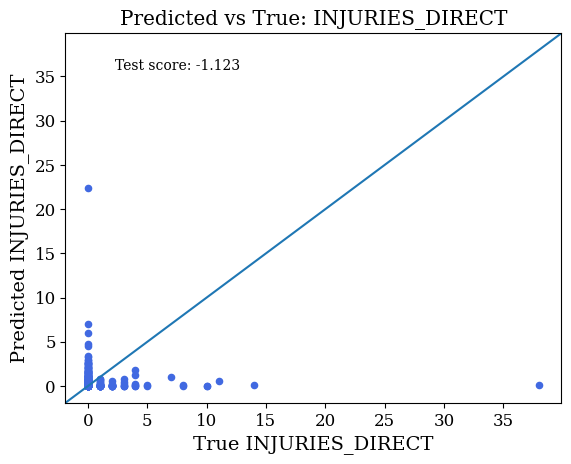

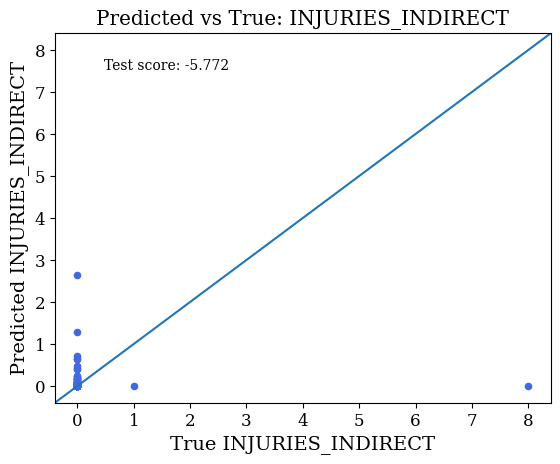

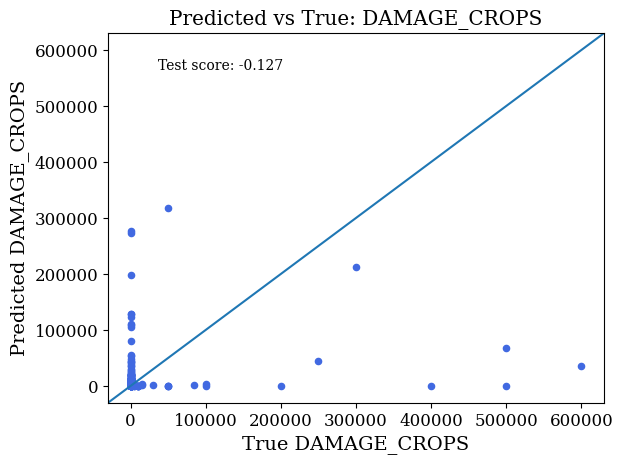

In [147]:
for i in range(5):
    plt.figure()
    plt.plot([0, 1], [0, 1], transform=plt.gca().transAxes)
    plt.scatter(targets[targets.columns[i]],targets_pred[:,i], s = 20, c = 'royalblue')
    plt.xlabel('True ' + targets.columns[i], fontsize=14)
    plt.ylabel('Predicted ' + targets.columns[i],fontsize=14)
    #plt.axis('square')
    plt.text(0.1, .9, 'Test score: ' + str("{:.3f}".format(np.mean(scores[i]['test_score']))), fontsize = 10, transform=plt.gca().transAxes)
    #plt.xscale('log')
    #plt.yscale('log')
    lower = min(plt.xlim()[0], plt.ylim()[0])
    upper = max(plt.xlim()[1], plt.ylim()[1])
    plt.title("Predicted vs True: " + targets.columns[i])
    plt.xlim(lower,upper)
    plt.ylim(lower, upper)

In [142]:
# https://scikit-learn.org/stable/auto_examples/miscellaneous/plot_roc_curve_visualization_api.html
from sklearn.metrics import RocCurveDisplay

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features, targets, random_state=42, test_size=0.3)


from sklearn.metrics import roc_curve, auc


forest_model.fit(X_train, y_train)

y_pred_continuous = forest_model.predict(X_test)

evaluation_threshold = 0.0 
y_test_binary = (y_test > evaluation_threshold).astype(int)

fpr, tpr, thresholds = roc_curve(y_test_binary, y_pred_continuous)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # Random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve using Random Forest Regressor Outputs')
plt.legend(loc="lower right")
plt.show()

ValueError: multilabel-indicator format is not supported

In [146]:
X = pd.DataFrame({
    'BEGIN_LAT': data_f['BEGIN_LAT'],
    #'BEGIN_LON': data_f['BEGIN_LON'],
    'INJURIES_TOT': data_f['INJURIES_DIRECT'] + data_f['INJURIES_INDIRECT']
})

pca = PCA(n_components = 2)
## Fit the data
pca.fit(X)

pca.components_

array([[-0.01369714,  0.99990619],
       [ 0.99990619,  0.01369714]])

In [147]:
pca.explained_variance_

array([103.41274254,  23.59686533])

<>:21: SyntaxWarning: invalid escape sequence '\c'
<>:21: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_148718/1099978459.py:21: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('BEGIN LAT [$^{\circ}$]')


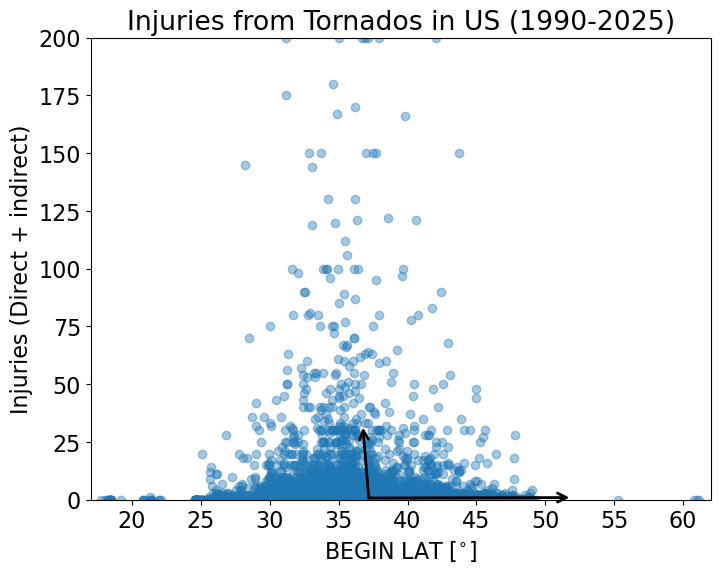

In [148]:
## This function will draw a vector in 2D
## given its components
def draw_vector(v0, v1, ax=None):
    ax = ax or plt.gca()
    arrowprops=dict(arrowstyle='->',
                    linewidth=2,
                    shrinkA=0, 
                    shrinkB=0,
                    color="black")
    ax.annotate('', v1, v0, arrowprops=arrowprops)

# plot data
plt.figure(figsize=(8,6))
plt.scatter(data_f['BEGIN_LAT'], 
            data_f['INJURIES_DIRECT']+data_f['INJURIES_INDIRECT'], alpha=.4)

for length, vector in zip(pca.explained_variance_, pca.components_):
    v = vector * 3 * np.sqrt(length)
    draw_vector(pca.mean_, pca.mean_ + v)
    
plt.xlabel('BEGIN LAT [$^{\circ}$]')
plt.ylabel('Injuries (Direct + indirect)')
plt.title('Injuries from Tornados in US (1990-2025)')

plt.xlim([17,62])
plt.ylim([0,200])
plt.show()

<>:33: SyntaxWarning: invalid escape sequence '\c'
<>:33: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_148718/3339186993.py:33: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('BEGIN LON [$^{\circ}$]')


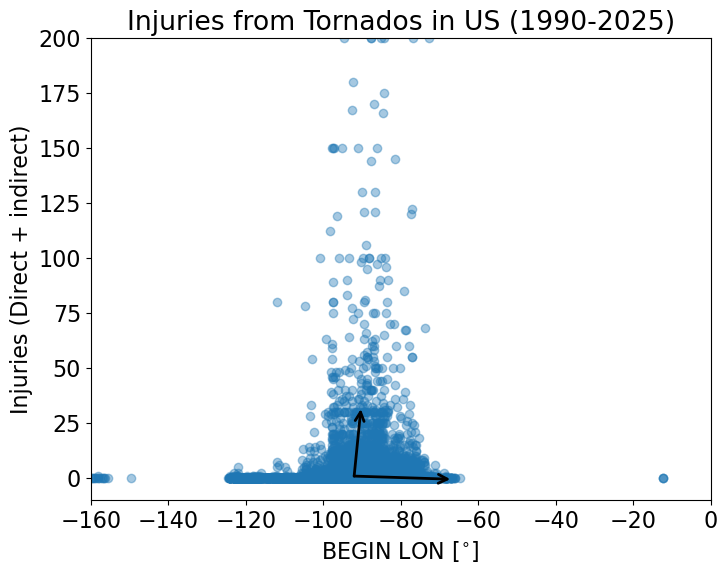

In [149]:
Xlon = pd.DataFrame({
    'BEGIN_LON': data_f['BEGIN_LON'],
    'INJURIES_TOT': data_f['INJURIES_DIRECT'] + data_f['INJURIES_INDIRECT']
})

pca = PCA(n_components = 2)
## Fit the data
pca.fit(Xlon)

pca.components_

## This function will draw a vector in 2D
## given its components
def draw_vector(v0, v1, ax=None):
    ax = ax or plt.gca()
    arrowprops=dict(arrowstyle='->',
                    linewidth=2,
                    shrinkA=0, 
                    shrinkB=0,
                    color="black")
    ax.annotate('', v1, v0, arrowprops=arrowprops)

# plot data
plt.figure(figsize=(8,6))
plt.scatter(data_f['BEGIN_LON'], 
            data_f['INJURIES_DIRECT']+data_f['INJURIES_INDIRECT'], alpha=.4)

for length, vector in zip(pca.explained_variance_, pca.components_):
    v = vector * 3 * np.sqrt(length)
    draw_vector(pca.mean_, pca.mean_ + v)
    
    
plt.xlabel('BEGIN LON [$^{\circ}$]')
plt.ylabel('Injuries (Direct + indirect)')
plt.title('Injuries from Tornados in US (1990-2025)')

plt.xlim([-160,0])
plt.ylim([-10,200])
plt.show()

In [151]:
# import matplotlib.pyplot as plt

# # unused but required import for doing 3d projections with matplotlib < 3.2
# import mpl_toolkits.mplot3d  # noqa: F401

# from sklearn.decomposition import PCA

# fig = plt.figure(1, figsize=(8, 6))
# ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)

# X_reduced = PCA(n_components=2).fit_transform(X)
# scatter = ax.scatter(
#     X_reduced[:, 0],
#     X_reduced[:, 1],
#     X_reduced[:, 2],
#     c=['BEGIN_LAT', 'BEGIN_LON', 'INJURIES'],
#     s=40,
# )

# ax.set(
#     title="First three principal components",
#     xlabel="1st Principal Component",
#     ylabel="2nd Principal Component",
#     zlabel="3rd Principal Component",
# )
# ax.xaxis.set_ticklabels([])
# ax.yaxis.set_ticklabels([])
# ax.zaxis.set_ticklabels([])

# # Add a legend
# legend1 = ax.legend(
#     scatter.legend_elements()[0],
#     iris.target_names.tolist(),
#     loc="upper right",
#     title="Classes",
# )
# ax.add_artist(legend1)

# plt.show()